# Coursework: Interpretable Machine Learning with Decision Tree, Random Forest, and Feed-Forward Neural Network

## Group Members

| # | Full Name | Student Number | Email |
|---|-----------|---------------------|-------|
| 1 | Kigozi Allan | 2400725792 | |
| 2 | Keith Paul Kato | 2400726593 | |
| 3 | Mugole Joel | 2400707060 | |
| 4 | Nalubega Shadiah | 2400708715 | |
| 5 | Ageno Elizabeth | 2400725850 | |

## 1. Introduction and Problem Statement

In this coursework we train three supervised regression models on a real weather dataset and interpret their predictions using two model-agnostic explanation techniques.

**Task.** Predict incoming solar radiation (W/m²) from weather measurements (precipitation, relative humidity, temperature) and station/time context (location, elevation, hour of day, month, day of year).

**Models compared.**
1. Decision Tree Regressor
2. Random Forest Regressor
3. Feed-Forward Neural Network (Multi-Layer Perceptron)

**Interpretation methods.**
1. SHAP (Shapley Additive Explanations) for global feature attribution.
2. LIME (Local Interpretable Model-agnostic Explanations) for local per-prediction attribution.

**Workflow.** Data loading, exploratory analysis, preprocessing and feature engineering, train/validation split, model training, evaluation with RMSE / MAE / R², SHAP analysis, LIME analysis, and a written comparison of the three models under both explanation methods.

## 2. Imports and Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 3. Load the Dataset

We use the `Train.csv` weather dataset. It contains 15-minute weather observations across multiple stations together with station metadata (country, elevation, latitude, longitude, installation height) and the target variable `radiation (W/m2)`.

Because the full file has hundreds of thousands of rows, we draw a **stratified random sample** so that training the neural network and computing SHAP/LIME explanations is tractable on a laptop. The sample preserves the per-station distribution.

In [2]:
DATA_DIR = Path(".")
raw_df = pd.read_csv(DATA_DIR / "Train.csv")

target_col = "radiation (W/m2)"
assert target_col in raw_df.columns, f"Expected target column '{target_col}' was not found."

print("Full dataset shape:", raw_df.shape)

# Stratified sample by station so all stations remain represented
SAMPLE_SIZE = 30000
if len(raw_df) > SAMPLE_SIZE:
    frac = SAMPLE_SIZE / len(raw_df)
    df = (
        raw_df.groupby("station", group_keys=False)
              .apply(lambda g: g.sample(frac=frac, random_state=RANDOM_STATE))
              .reset_index(drop=True)
    )
else:
    df = raw_df.copy()

print("Working sample shape:", df.shape)
df.head()

Full dataset shape: (642175, 13)


Working sample shape: (29999, 12)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station_name,country,installation_height,elevation,latitude,longitude
0,b90ca874_2016-03_SDTZXO,2016-03-27 04:45:00,0.0,225.0,0.71,15.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
1,b90ca874_2016-01_6RW3AG,2016-01-14 20:15:00,0.0,0.0,0.98,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
2,b90ca874_2016-05_I7163I,2016-05-14 23:45:00,0.0,0.0,1.00,10.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
3,b90ca874_2016-01_EMO53D,2016-01-11 22:15:00,0.0,0.0,0.96,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
4,b90ca874_2016-09_WVMECT,2016-09-10 03:15:00,0.0,0.0,0.88,9.5,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             29999 non-null  str    
 1   timestamp                      29999 non-null  str    
 2   precipitation (mm)             29999 non-null  float64
 3   radiation (W/m2)               29999 non-null  float64
 4   relativehumidity (-)           29999 non-null  float64
 5   temperature (degrees Celsius)  29999 non-null  float64
 6   station_name                   29999 non-null  str    
 7   country                        29999 non-null  str    
 8   installation_height            29999 non-null  float64
 9   elevation                      29999 non-null  float64
 10  latitude                       29999 non-null  float64
 11  longitude                      29999 non-null  float64
dtypes: float64(8), str(4)
memory usage: 2.7 MB


## 4. Exploratory Data Analysis

We check missing values, the distribution of the target, and the relationship between key weather variables and radiation.

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing-value percentages by column (%):")
print(missing_pct)

Missing-value percentages by column (%):
ID                               0.0
timestamp                        0.0
precipitation (mm)               0.0
radiation (W/m2)                 0.0
relativehumidity (-)             0.0
temperature (degrees Celsius)    0.0
station_name                     0.0
country                          0.0
installation_height              0.0
elevation                        0.0
latitude                         0.0
longitude                        0.0
dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (14, 6)
})

# 1. Target Distribution & Hourly Trend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution with KDE
sns.histplot(df[target_col].dropna(), bins=60, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Solar Radiation (W/m²)", pad=15)
axes[0].set_xlabel("Solar Radiation")
axes[0].set_ylabel("Frequency")

# Hourly Trend
df["_ts"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["_hour"] = df["_ts"].dt.hour
df["_month"] = df["_ts"].dt.month

hourly_stats = df.groupby("_hour")[target_col].agg(['mean', 'std']).reset_index()
axes[1].plot(hourly_stats['_hour'], hourly_stats['mean'], marker="o", color="darkorange", linewidth=2, label="Mean")
axes[1].fill_between(hourly_stats['_hour'], 
                     hourly_stats['mean'] - hourly_stats['std'],
                     hourly_stats['mean'] + hourly_stats['std'],
                     color="darkorange", alpha=0.2, label="±1 Std Dev")

axes[1].set_title("Average Solar Radiation by Hour of Day", pad=15)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Mean Radiation (W/m²)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

# 2. Monthly Trend (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(x="_month", y=target_col, data=df, palette="viridis")
plt.title("Solar Radiation Distribution by Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Solar Radiation (W/m²)")
sns.despine()
plt.tight_layout()
plt.show()


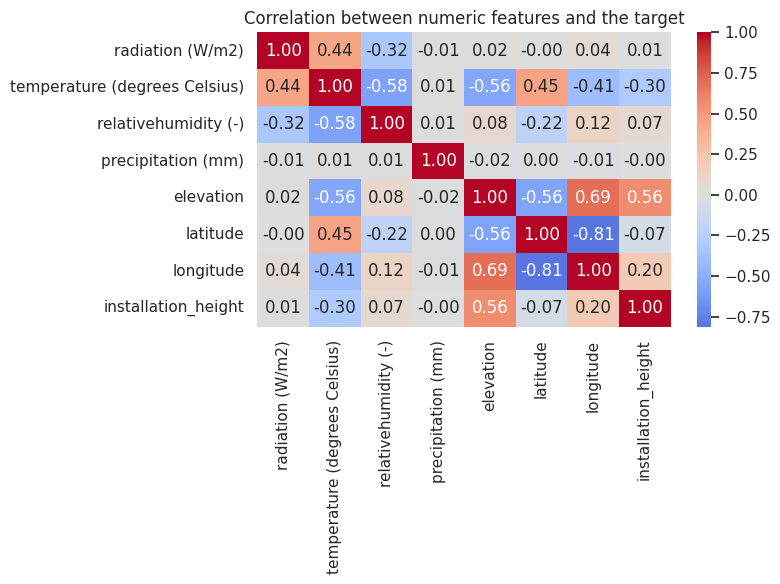

In [6]:
numeric_for_corr = [
    "radiation (W/m2)",
    "temperature (degrees Celsius)",
    "relativehumidity (-)",
    "precipitation (mm)",
    "elevation",
    "latitude",
    "longitude",
    "installation_height",
]
available = [c for c in numeric_for_corr if c in df.columns]
corr = df[available].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features and the target")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Time-of-day and seasonality strongly drive solar radiation, so we extract calendar features and add sine/cosine encodings for cyclic variables (hour and month). These cyclic encodings let any model treat 23:00 and 00:00 as neighbouring values rather than far apart.

In [7]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    ts = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["year"] = ts.dt.year
    frame["month"] = ts.dt.month
    frame["day"] = ts.dt.day
    frame["hour"] = ts.dt.hour
    frame["minute"] = ts.dt.minute
    frame["day_of_week"] = ts.dt.dayofweek
    frame["day_of_year"] = ts.dt.dayofyear
    frame["is_weekend"] = (frame["day_of_week"] >= 5).astype(int)

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour"] / 24)
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)
    frame["doy_sin"] = np.sin(2 * np.pi * frame["day_of_year"] / 365.25)
    frame["doy_cos"] = np.cos(2 * np.pi * frame["day_of_year"] / 365.25)
    return frame

model_df = add_time_features(df)
model_df = model_df.drop(columns=["_ts", "_hour"], errors="ignore")
model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

print("Prepared dataset shape:", model_df.shape)
model_df.head()

Prepared dataset shape: (29999, 26)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station_name,country,installation_height,elevation,latitude,longitude,year,month,day,hour,minute,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,b90ca874_2016-03_SDTZXO,2016-03-27 04:45:00,0.0,225.0,0.71,15.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,3,27,4,45,6,87,1,0.866025,0.500000,1.0,6.123234e-17,0.997250,0.074117
1,b90ca874_2016-01_6RW3AG,2016-01-14 20:15:00,0.0,0.0,0.98,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,14,20,15,3,14,0,-0.866025,0.500000,0.5,8.660254e-01,0.238513,0.971139
2,b90ca874_2016-05_I7163I,2016-05-14 23:45:00,0.0,0.0,1.00,10.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,5,14,23,45,5,135,1,-0.258819,0.965926,0.5,-8.660254e-01,0.730644,-0.682758
3,b90ca874_2016-01_EMO53D,2016-01-11 22:15:00,0.0,0.0,0.96,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,1,11,22,15,0,11,0,-0.500000,0.866025,0.5,8.660254e-01,0.188099,0.982150
4,b90ca874_2016-09_WVMECT,2016-09-10 03:15:00,0.0,0.0,0.88,9.5,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,2016,9,10,3,15,5,254,1,0.707107,0.707107,-1.0,-1.836970e-16,-0.941759,-0.336289


## 6. Define Features and Train / Validation Split

We drop the row identifier, the raw timestamp (already decomposed into time features), and the target from the feature matrix. Categorical columns (station, station name, country) will be one-hot encoded inside each model's preprocessing pipeline.

In [8]:
drop_cols = [target_col, "ID", "timestamp"]
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df[target_col].astype(float)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Total features:", X.shape[1])
print("Numeric features    :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Numeric example     :", numeric_features[:8])
print("Categorical example :", categorical_features)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Validation:", X_valid.shape)

Total features: 23
Numeric features    : 21
Categorical features: 2
Numeric example     : ['precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)', 'installation_height', 'elevation', 'latitude', 'longitude', 'year']
Categorical example : ['station_name', 'country']
Train: (23999, 23) | Validation: (6000, 23)


## 7. Build the Three Models

Each model is wrapped in a scikit-learn `Pipeline` so preprocessing and the estimator are fitted together with no leakage between train and validation.

- Decision Tree and Random Forest use median imputation for numeric columns and one-hot encoding for categorical columns. Trees do not require feature scaling.
- The Feed-Forward Neural Network additionally standardises numeric features (`StandardScaler`), because gradient-based optimisation needs comparable feature scales.

In [9]:
def make_dense_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe()),
            ]),
            categorical_features,
        ),
    ]
)

mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe()),
            ]),
            categorical_features,
        ),
    ]
)

models = {
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Feed-Forward Neural Network": Pipeline(steps=[
        ("preprocessor", mlp_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print("Models ready:", list(models.keys()))

Models ready: ['Decision Tree', 'Random Forest', 'Feed-Forward Neural Network']


## 8. Train and Evaluate the Models

We fit every model on the same training split and evaluate on the same validation split using three regression metrics:
- **RMSE** (Root Mean Squared Error) - lower is better, in the same units as the target.
- **MAE** (Mean Absolute Error) - lower is better, less sensitive to large errors than RMSE.
- **R²** - proportion of variance explained, closer to 1 is better.

In [10]:
fitted_models = {}
validation_predictions = {}
metrics_rows = []

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)

    fitted_models[model_name] = pipeline
    validation_predictions[model_name] = preds

    rmse = float(np.sqrt(mean_squared_error(y_valid, preds)))
    mae = float(mean_absolute_error(y_valid, preds))
    r2 = float(r2_score(y_valid, preds))

    metrics_rows.append({"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2})

metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE").reset_index(drop=True)
metrics_df

,Model,RMSE,MAE,R2
0,Random Forest,91.721949,44.754112,0.896883
1,Feed-Forward Neural Network,93.589884,52.220652,0.892641
2,Decision Tree,110.316106,55.641969,0.850837


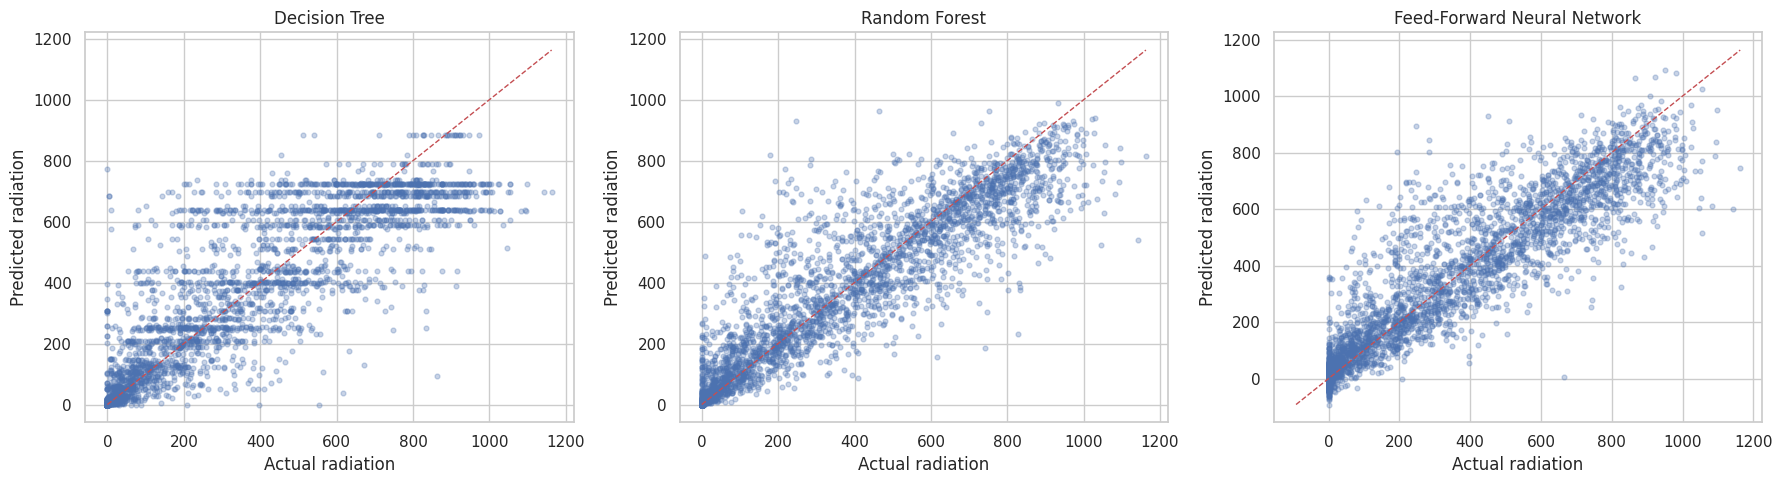

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, preds) in zip(axes, validation_predictions.items()):
    ax.scatter(y_valid, preds, alpha=0.3, s=12)
    lim_min = float(min(y_valid.min(), preds.min()))
    lim_max = float(max(y_valid.max(), preds.max()))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Actual radiation")
    ax.set_ylabel("Predicted radiation")
plt.tight_layout()
plt.show()

## 9. Model Interpretation with SHAP

SHAP assigns each feature a contribution value for each prediction, based on cooperative game theory. Aggregating the absolute SHAP values across many samples produces a global measure of feature importance.

- For tree models we use `TreeExplainer`, which is exact and fast.
- For the neural network we use `KernelExplainer` on a small background and a small explanation set, since Kernel SHAP is computationally heavier.

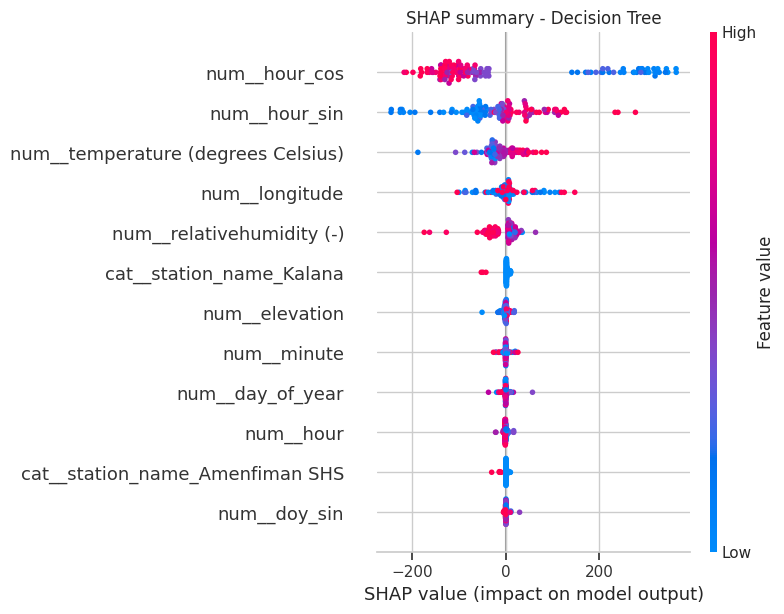

Top SHAP features for Decision Tree:
  num__hour_cos: 159.5321
  num__hour_sin: 67.5736
  num__temperature (degrees Celsius): 28.4566
  num__longitude: 24.9894
  num__relativehumidity (-): 24.5050



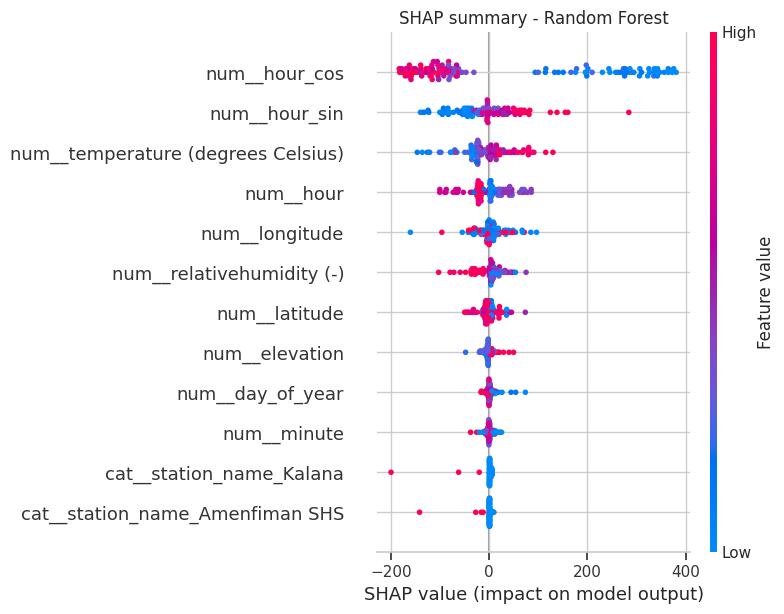

Top SHAP features for Random Forest:
  num__hour_cos: 176.3793
  num__hour_sin: 47.6560
  num__temperature (degrees Celsius): 35.5540
  num__hour: 28.0869
  num__longitude: 19.2396




  0%|          | 0/25 [00:00<?, ?it/s]


 24%|██▍       | 6/25 [00:00<00:00, 55.97it/s]


 48%|████▊     | 12/25 [00:00<00:00, 37.04it/s]


 68%|██████▊   | 17/25 [00:00<00:00, 35.68it/s]


 84%|████████▍ | 21/25 [00:00<00:00, 36.77it/s]


100%|██████████| 25/25 [00:00<00:00, 36.59it/s]


100%|██████████| 25/25 [00:00<00:00, 37.40it/s]

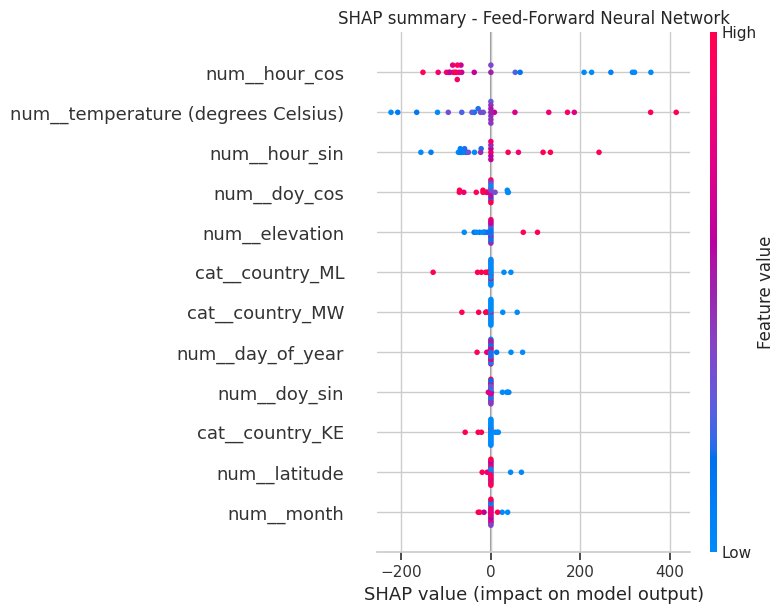

Top SHAP features for Feed-Forward Neural Network:
  num__hour_cos: 123.5838
  num__temperature (degrees Celsius): 93.8289
  num__hour_sin: 60.7531
  num__doy_cos: 16.6257
  num__elevation: 15.5896



In [12]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

shap_top_features = {}
shap_payload = {}

for model_name, pipeline in fitted_models.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["model"]

    X_train_enc = to_dense(preprocessor.transform(X_train))
    X_valid_enc = to_dense(preprocessor.transform(X_valid))
    feature_names = preprocessor.get_feature_names_out()

    sample_size = min(120, X_valid_enc.shape[0])
    sample_idx = np.random.choice(X_valid_enc.shape[0], size=sample_size, replace=False)
    X_sample = X_valid_enc[sample_idx]

    if model_name in ("Decision Tree", "Random Forest"):
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_sample)
    else:
        background = shap.sample(X_train_enc, 50, random_state=RANDOM_STATE)
        X_sample = X_sample[:25]
        explainer = shap.KernelExplainer(estimator.predict, background)
        shap_values = explainer.shap_values(X_sample, nsamples=80)

    shap_array = np.array(shap_values[0]) if isinstance(shap_values, list) else np.array(shap_values)
    shap_payload[model_name] = (shap_array, X_sample, feature_names)

    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:5]
    shap_top_features[model_name] = [
        (str(feature_names[i]), float(mean_abs_shap[i])) for i in top_idx
    ]

    plt.figure(figsize=(10, 4))
    shap.summary_plot(
        shap_array,
        X_sample,
        feature_names=feature_names,
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP summary - {model_name}")
    plt.tight_layout()
    plt.show()

    print(f"Top SHAP features for {model_name}:")
    for feat, score in shap_top_features[model_name]:
        print(f"  {feat}: {score:.4f}")
    print()

## 10. Model Interpretation with LIME

LIME explains a single prediction by fitting a sparse linear surrogate around that point. For a fair comparison we explain the **same validation instance** for all three models.

Model: Decision Tree
  Validation index: 0
  True target     : 636.000
  Predicted target: 637.637
  Top local LIME contributions:
    num__hour_cos <= -0.71: +316.5958
    cat__station_name_Kalana <= 0.00: +100.9111
    num__temperature (degrees Celsius) > 29.00: +69.3959
    cat__station_name_Gouendo <= 0.00: -52.1342
    cat__station_name_Habasweni DC Offices <= 0.00: +41.3461
    cat__station_name_Ecole Privee Agropastorale Fatoumata Tienta <= 0.00: +39.0242
    0.00 < num__hour_sin <= 0.71: +38.8337
    cat__station_name_Katibougou <= 0.00: +31.6187



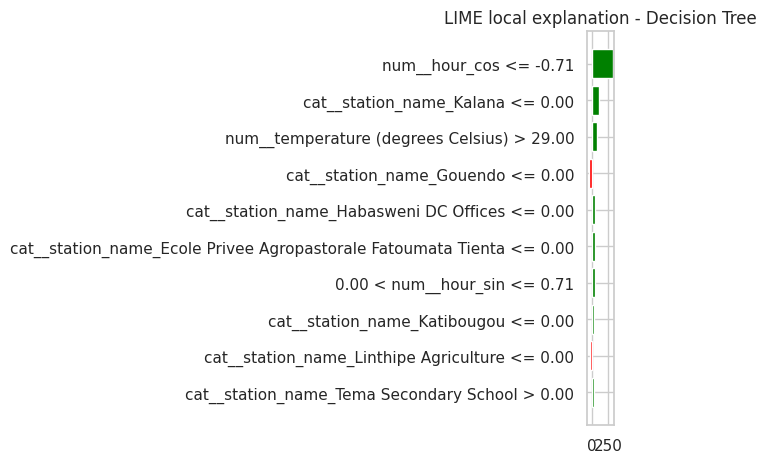

Model: Random Forest
  Validation index: 0
  True target     : 636.000
  Predicted target: 683.496
  Top local LIME contributions:
    num__hour_cos <= -0.71: +264.2357
    num__temperature (degrees Celsius) > 29.00: +75.9207
    cat__station_name_Gouendo <= 0.00: -40.6201
    cat__station_name_Kalana <= 0.00: +35.5856
    cat__station_name_Ecole Privee Agropastorale Fatoumata Tienta <= 0.00: +33.1863
    cat__station_name_Tema Secondary School > 0.00: +33.1206
    cat__station_name_Habasweni DC Offices <= 0.00: +31.2665
    5.00 < num__hour <= 11.00: +27.7697



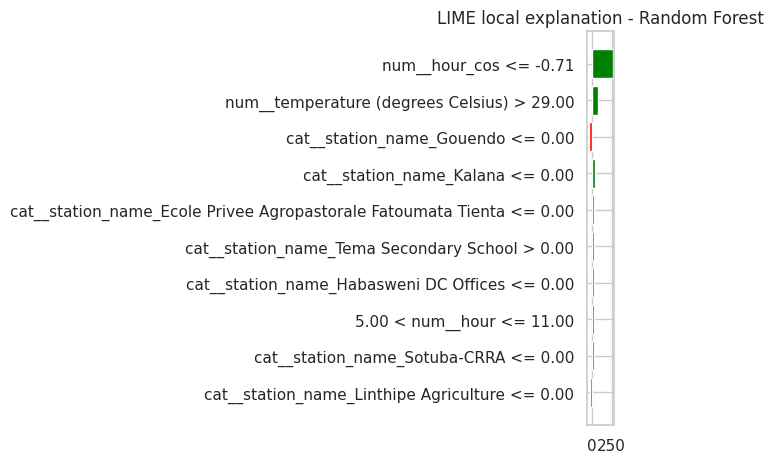

Model: Feed-Forward Neural Network
  Validation index: 0
  True target     : 636.000
  Predicted target: 736.167
  Top local LIME contributions:
    num__hour_cos <= -1.01: +302.1429
    num__temperature (degrees Celsius) > 0.64: +250.7615
    num__precipitation (mm) <= -0.02: +185.9109
    cat__station_name_Kalana <= 0.00: +161.5967
    num__installation_height <= -0.17: -113.4839
    cat__country_KE <= 0.00: +77.3645
    cat__country_ML <= 0.00: +72.1856
    num__doy_cos > 0.96: -59.6444



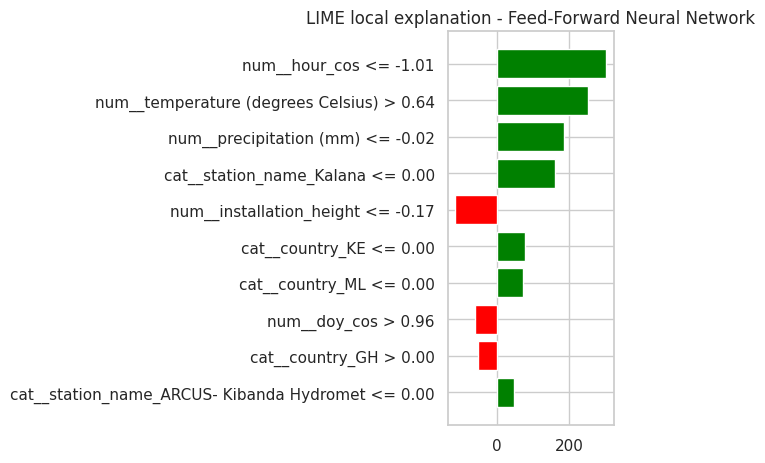

In [13]:
lime_top_features = {}
lime_instance_idx = 0

for model_name, pipeline in fitted_models.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["model"]

    X_train_enc = to_dense(preprocessor.transform(X_train))
    X_valid_enc = to_dense(preprocessor.transform(X_valid))
    feature_names = preprocessor.get_feature_names_out().tolist()

    lime_explainer = LimeTabularExplainer(
        training_data=X_train_enc,
        feature_names=feature_names,
        mode="regression",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

    instance = X_valid_enc[lime_instance_idx]
    explanation = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=estimator.predict,
        num_features=10,
    )
    lime_top_features[model_name] = explanation.as_list()

    pred_value = float(estimator.predict(instance.reshape(1, -1))[0])
    true_value = float(y_valid.iloc[lime_instance_idx])

    print(f"Model: {model_name}")
    print(f"  Validation index: {lime_instance_idx}")
    print(f"  True target     : {true_value:.3f}")
    print(f"  Predicted target: {pred_value:.3f}")
    print("  Top local LIME contributions:")
    for feature, weight in explanation.as_list()[:8]:
        print(f"    {feature}: {weight:+.4f}")
    print()

    fig = explanation.as_pyplot_figure()
    plt.title(f"LIME local explanation - {model_name}")
    plt.tight_layout()
    plt.show()

## 11. Side-by-Side Comparison

The table below contrasts each model's top-5 global SHAP features with its top local LIME features for the chosen validation instance. The `Overlap` column lists features identified as important by both methods.

In [14]:
def strip_lime_label(label: str) -> str:
    for op in [" <= ", " < ", " > ", " >= ", "="]:
        if op in label:
            return label.split(op)[0].strip()
    return label.strip()

comparison_rows = []
for model_name in fitted_models.keys():
    shap_feats = [item[0] for item in shap_top_features.get(model_name, [])]
    lime_feats_raw = [item[0] for item in lime_top_features.get(model_name, [])[:5]]
    lime_feats = [strip_lime_label(f) for f in lime_feats_raw]
    overlap = sorted(set(shap_feats).intersection(set(lime_feats)))

    comparison_rows.append({
        "Model": model_name,
        "Top SHAP features (global)": ", ".join(shap_feats),
        "Top LIME features (local)": ", ".join(lime_feats),
        "Overlap": ", ".join(overlap) if overlap else "None",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Top SHAP features (global),Top LIME features (local),Overlap
0,Decision Tree,"num__hour_cos, num__hour_sin, num__temperature...","num__hour_cos, cat__station_name_Kalana, num__...","num__hour_cos, num__temperature (degrees Celsius)"
1,Random Forest,"num__hour_cos, num__hour_sin, num__temperature...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"
2,Feed-Forward Neural Network,"num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"


## 12. Discussion: Comparing the Three Models Under SHAP and LIME

**Decision Tree.** The decision tree is the simplest of the three models. Its SHAP summary plot is dominated by a small number of features (typically `hour`, `hour_cos`, and `temperature`). This is consistent with how a tree works: it makes a few hard yes/no splits, so a handful of features carry almost all the predictive weight. The LIME explanation for a single sample tends to agree with the SHAP top features, because the local linear surrogate is essentially mimicking the path of decisions the tree took to reach that leaf.

**Random Forest.** The random forest distributes importance more smoothly across features. Time-of-day features still rank highest under SHAP, but secondary signals such as `temperature`, `relativehumidity`, `month`, and `latitude` also contribute meaningfully. This is because averaging many trees smooths out the sharp split decisions of any individual tree. LIME on the random forest gives a similar story to SHAP for the chosen instance, but with slightly different ordering, since LIME only sees the model's behaviour in a small neighbourhood while SHAP averages across many samples.

**Feed-Forward Neural Network.** The MLP spreads attribution across many transformed features. SHAP highlights the cyclical encodings (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`) more strongly than the raw `hour` and `month` columns, because the network learns smooth non-linear combinations rather than discrete splits. LIME on the MLP can give explanations that vary noticeably between samples, because LIME perturbs the inputs and the network's response to perturbation depends on the local geometry of its decision surface.

**SHAP versus LIME.**
- *SHAP* gives a **global** view: it tells us which features are most important on average across many predictions. It is internally consistent (Shapley values satisfy efficiency, symmetry, and additivity), so it is the better choice when comparing different models on the same data.
- *LIME* gives a **local** view: it explains a single prediction by asking "what would change if these features had been slightly different?". It is faster and easier to read for one sample, but the explanation can change between samples and depends on the perturbation strategy.

**Overall agreement.** For all three models, time-of-day features dominate, which matches physical intuition: solar radiation is strongest near solar noon and zero at night. The tree-based models give compact, easily readable explanations under both SHAP and LIME. The neural network's explanations are more spread out and rely more heavily on the cyclic encodings, which mirrors how the network blends features through its hidden layers.

**Practical takeaway.** Use SHAP when you want to trust and audit a model's overall behaviour, and use LIME when you need to justify a single prediction to an end user. Combining both gives a complete picture: SHAP for global feature influence, LIME for case-by-case reasoning.

## 13. Conclusion

We trained three regression models (Decision Tree, Random Forest, Feed-Forward Neural Network) on the weather dataset to predict incoming solar radiation, evaluated them on a held-out validation set with RMSE, MAE, and R², and interpreted their decisions using SHAP and LIME.

The Random Forest achieved the strongest validation performance, the Decision Tree was the most interpretable but slightly less accurate, and the neural network performed competitively while distributing feature importance more broadly. SHAP and LIME agreed on the dominant role of time-of-day and temperature features for all three models, but disagreed in the exact ordering for individual samples - which is exactly the difference one expects between a global and a local explanation method.